<a href="https://colab.research.google.com/github/Toni-Amadike/georad-sprint2-market-data/blob/main/sprint4_satellite_imagery_to_spatial_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee

# Set your Earth Engine Cloud project ID (required for newer EE clients).
# Example: EE_PROJECT = "georad-academy-ee"
EE_PROJECT = ""  # <-- paste your project ID here

try:
    from google.colab import userdata  # type: ignore
    secret_project = userdata.get("EE_PROJECT")
    if secret_project and not EE_PROJECT:
        EE_PROJECT = secret_project
except Exception:
    pass

if not EE_PROJECT:
    raise ValueError(
        "Set EE_PROJECT to your Google Cloud / Earth Engine project ID "
        "(or add Colab Secret EE_PROJECT)."
    )

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)
print(f"Earth Engine initialized for project: {EE_PROJECT}")


Earth Engine initialized for project: georad-academy-ee-510609


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [2]:
import ee

# Set your Earth Engine Cloud project ID (required for newer EE clients).
# Example: EE_PROJECT = "georad-academy-ee"
EE_PROJECT = ""  # <-- paste your project ID here

try:
    from google.colab import userdata  # type: ignore
    secret_project = userdata.get("EE_PROJECT")
    if secret_project and not EE_PROJECT:
        EE_PROJECT = secret_project
except Exception:
    pass

if not EE_PROJECT:
    raise ValueError(
        "Set EE_PROJECT to your Google Cloud / Earth Engine project ID "
        "(or add Colab Secret EE_PROJECT)."
    )

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)
print(f"Earth Engine initialized for project: {EE_PROJECT}")


Earth Engine initialized for project: georad-academy-ee-510609


# Sprint 4: From Satellite Imagery to Spatial Intelligence

**GeoRAD Emerging Spatial Professionals Mentorship Program · Week 5**

This notebook helps you:

1. **Map your five towns** (spatial orientation first)
2. Connect to **Google Earth Engine**
3. Compare **2016** and **2026** satellite imagery for each town
4. Measure **Development Change** and assign Low / Average / High
5. Chart and map the results
6. Experiment with the workflow

You do **not** need to build a remote-sensing pipeline from scratch. Focus on understanding the workflow, running it, inspecting imagery and numbers, and thinking like a spatial analyst.

> Development Change describes what has been **observed** between 2016 and 2026. It is **not** a prediction of future development.


## 0. Install packages

Run once per Colab session.


In [3]:
# Earth Engine client + tables, charts, maps
%pip install -q earthengine-api pandas matplotlib geopandas folium mapclassify


## 1. Map your towns (spatial orientation)

Start with the map.

Upload the **same towns GeoJSON** you used in earlier sprints (five towns; name field usually `ward`).


In [4]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

try:
    from google.colab import files  # type: ignore
    print("Upload your towns GeoJSON (Sprint 1 selected towns).")
    geo_uploaded = files.upload()
    GEOJSON_PATH = next(iter(geo_uploaded))
except Exception:
    GEOJSON_PATH = "sample_towns.geojson"

gdf = gpd.read_file(GEOJSON_PATH)
print(f"Loaded GeoJSON: {GEOJSON_PATH}")
print(f"Features: {len(gdf)} | CRS: {gdf.crs}")
print(f"Geometry types: {Counter(gdf.geometry.geom_type)}")
print(f"Property columns: {list(gdf.columns)}")

PREFERRED_NAME_FIELDS = ["ward", "town", "town_name", "name", "NAME", "Town"]
TOWN_NAME_FIELD = "wardname"  # Override to match your GeoJSON column

if TOWN_NAME_FIELD is None:
    for field in PREFERRED_NAME_FIELDS:
        if (
            field in gdf.columns
            and gdf[field].notna().all()
            and (gdf[field].astype(str).str.strip() != "").all()
        ):
            TOWN_NAME_FIELD = field
            break

if TOWN_NAME_FIELD is None:
    raise ValueError(
        "Could not detect a town-name field. Set TOWN_NAME_FIELD manually. "
        f"Columns: {list(gdf.columns)}"
    )

print(f"Using town-name field: {TOWN_NAME_FIELD}")
gdf = gdf.copy()
gdf["Location"] = gdf[TOWN_NAME_FIELD].astype(str).str.strip()
print("Locations:", sorted(gdf["Location"].unique().tolist()))


def folium_safe_gdf(frame: gpd.GeoDataFrame, keep_cols: list) -> gpd.GeoDataFrame:
    """Keep only map fields and stringify values Folium cannot JSON-encode."""
    cols = [c for c in keep_cols if c in frame.columns]
    out = frame[cols + ["geometry"]].copy()
    for col in cols:
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = out[col].astype(str)
        else:
            out[col] = out[col].map(
                lambda v: None
                if v is None or (isinstance(v, float) and np.isnan(v))
                else str(v)
                if not isinstance(v, (str, int, float, bool))
                else v
            )
    return out


towns_wgs = gdf.to_crs(epsg=4326) if gdf.crs and gdf.crs.to_epsg() != 4326 else gdf.copy()
if towns_wgs.crs is None:
    towns_wgs = towns_wgs.set_crs(epsg=4326)

towns_map_gdf = folium_safe_gdf(towns_wgs, ["Location"])
minx, miny, maxx, maxy = towns_map_gdf.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]

BASEMAP_STREET = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Street_Map/MapServer/tile/{z}/{y}/{x}"
)
BASEMAP_SATELLITE = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Imagery/MapServer/tile/{z}/{y}/{x}"
)
BASEMAP_ATTR = "Tiles &copy; Esri"


def add_esri_basemaps(fmap: folium.Map) -> folium.Map:
    # Street + satellite basemaps. Toggle with the map layer control.
    folium.TileLayer(
        tiles=BASEMAP_STREET,
        attr=BASEMAP_ATTR,
        name="Esri Street",
        overlay=False,
        control=True,
        show=True,
    ).add_to(fmap)
    folium.TileLayer(
        tiles=BASEMAP_SATELLITE,
        attr=BASEMAP_ATTR,
        name="Esri Satellite",
        overlay=False,
        control=True,
        show=False,
    ).add_to(fmap)
    return fmap


towns_map = folium.Map(location=center, zoom_start=11, tiles=None)
add_esri_basemaps(towns_map)
geom_types = set(towns_map_gdf.geometry.geom_type)

if geom_types <= {"Point", "MultiPoint"}:
    towns_layer = folium.FeatureGroup(name="Towns", show=True)
    for _, row in towns_map_gdf.iterrows():
        geom = row.geometry
        pts = list(geom.geoms) if geom.geom_type == "MultiPoint" else [geom]
        for pt in pts:
            folium.CircleMarker(
                location=[pt.y, pt.x],
                radius=9,
                color="#1f4e79",
                fill=True,
                fill_color="#4a90c6",
                fill_opacity=0.85,
                popup=folium.Popup(f"<b>{row['Location']}</b>", max_width=240),
                tooltip=row["Location"],
            ).add_to(towns_layer)
    towns_layer.add_to(towns_map)
else:
    def style_town(_feature):
        return {
            "fillColor": "#4a90c6",
            "color": "#1f4e79",
            "weight": 1.5,
            "fillOpacity": 0.55,
        }

    folium.GeoJson(
        json.loads(towns_map_gdf.to_json()),
        name="Towns",
        style_function=style_town,
        tooltip=folium.GeoJsonTooltip(fields=["Location"]),
        popup=folium.GeoJsonPopup(fields=["Location"]),
    ).add_to(towns_map)

towns_map.fit_bounds([[miny, minx], [maxy, maxx]])
folium.LayerControl(collapsed=False).add_to(towns_map)
Path("sprint4_outputs").mkdir(exist_ok=True)
towns_map.save("sprint4_outputs/towns_orientation_map.html")
print("Saved: sprint4_outputs/towns_orientation_map.html")
towns_map

Upload your towns GeoJSON (Sprint 1 selected towns).


Saving Mosan_Okunola_Selected_WardsRPJ.geojson to Mosan_Okunola_Selected_WardsRPJ.geojson
Loaded GeoJSON: Mosan_Okunola_Selected_WardsRPJ.geojson
Features: 5 | CRS: EPSG:4326
Geometry types: Counter({'MultiPolygon': 5})
Property columns: ['FID', 'globalid', 'uniq_id', 'timestamp', 'editor', 'wardname', 'wardcode', 'lganame', 'lgacode', 'statename', 'statecode', 'amapcode', 'status', 'source', 'urban', 'geometry']
Using town-name field: wardname
Locations: ['Abesan 1', 'Abesan 2', 'Gowon Estate', 'Mosan / Akinoggun', 'Okunola']
Saved: sprint4_outputs/towns_orientation_map.html


## 2. Connect to Google Earth Engine

If this is your **first time** using Earth Engine on this Google account, complete the setup below before running the code cell.

### First-time setup (new Earth Engine account)

**1. Open the Earth Engine registration flow**

Go to: [https://code.earthengine.google.com/register](https://code.earthengine.google.com/register)

Sign in with the Google account you will use in Colab.

**2. Create a Cloud project**

In the registration wizard:

1. Choose **Create a new Google Cloud project** (do not pick a random existing one).
2. Accept Google Cloud terms if prompted.
3. Give it a clear name, e.g. `GeoRAD Academy EE` or `georad-sprint4-ee`.
4. Note the **Project ID** (lowercase, often like `georad-sprint4-ee-123456`). That is what goes in `EE_PROJECT` below. Use the project **ID**, not the display name.

**3. Choose noncommercial (for teaching / learning)**

For mentorship, classroom, or personal learning:

1. Select **Noncommercial**.
2. Pick the closest type (education / research / personal learning, depending on what Google shows).
3. Complete the eligibility questionnaire honestly.

You usually do **not** need billing for noncommercial teaching use. If Google routes you to commercial/billing, stop and re-check the noncommercial path.

**4. Confirm Earth Engine is ready**

1. Open [https://code.earthengine.google.com](https://code.earthengine.google.com).
2. Top-right account menu → **Change Cloud Project**.
3. Select the project you just created.
4. If the Code Editor loads without access errors, you are set.

**5. Wire it into this notebook**

1. In Colab, use the **same Google account** that owns the project.
2. Set `EE_PROJECT = "your-project-id-here"` in the next cell (or add a Colab Secret named `EE_PROJECT`).
3. Run the Earth Engine cell.
4. Complete `ee.Authenticate()` in the browser when prompted.
5. You should see: `Earth Engine initialized for project: ...`

Optional: store `EE_PROJECT` as a Colab Secret so you do not paste the ID into a shared notebook.

### Common blockers

- Wrong Google account in Colab vs the one that owns the project
- Using the project **name** instead of the project **ID**
- Skipping registration (a Cloud project alone is not enough; it must be registered for Earth Engine)
- Noncommercial questionnaire incomplete (access can stay blocked)

Official reference: [Earth Engine access / Cloud projects](https://developers.google.com/earth-engine/guides/access)

If you already authenticated in this runtime, you can re-run Initialize only.


In [5]:
import ee

# Set your Earth Engine Cloud project ID (required for newer EE clients).
# Example: EE_PROJECT = "georad-academy-ee"
EE_PROJECT = ""  # <-- paste your project ID here

try:
    from google.colab import userdata  # type: ignore
    secret_project = userdata.get("EE_PROJECT")
    if secret_project and not EE_PROJECT:
        EE_PROJECT = secret_project
except Exception:
    pass

if not EE_PROJECT:
    raise ValueError(
        "Set EE_PROJECT to your Google Cloud / Earth Engine project ID "
        "(or add Colab Secret EE_PROJECT)."
    )

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)
print(f"Earth Engine initialized for project: {EE_PROJECT}")


Earth Engine initialized for project: georad-academy-ee-510609


## 3. Analysis settings (standardized GeoRAD method)

| Setting | Default | Meaning |
| --- | --- | --- |
| Earlier year | 2016 | Baseline imagery year |
| Recent year | 2026 | Comparison imagery year |
| Sensor | Landsat 8/9 Surface Reflectance | Consistent optical record |
| Development metric | % of pixels with NDBI above threshold | Observed built-up proxy |
| NDBI threshold | 0.0 | Pixels above this count as "developed" for this teaching method |
| Scale | 30 m | Landsat resolution |

**Development Change** = Recent Development (%) − Earlier Development (%).

**Development Change Level** (product indicator):

| Level | Development Change (percentage points) |
| --- | --- |
| Low | less than 5 |
| Average | 5 to less than 15 |
| High | 15 or more |

These thresholds are the GeoRAD teaching defaults so everyone classifies consistently. They are **not** a formal planning standard.


In [6]:
EARLIER_YEAR = 2016
RECENT_YEAR = 2026
NDBI_THRESHOLD = 0.0 # Experiment later: try 0.05 or -0.05
ANALYSIS_SCALE_M = 30
MAX_CLOUD_COVER = 40

# Absolute classification thresholds (percentage points)
LOW_MAX = 5.0
AVERAGE_MAX = 15.0

print(
    f"Comparing {EARLIER_YEAR} vs {RECENT_YEAR} | "
    f"NDBI threshold={NDBI_THRESHOLD} | scale={ANALYSIS_SCALE_M}m"
)


Comparing 2016 vs 2026 | NDBI threshold=0.0 | scale=30m


## 4. Build the Earth Engine helpers

The workflow:

1. Build a cloud-masked Landsat median composite for a year  
2. Compute **NDBI** (Normalized Difference Built-up Index)  
3. Count the share of pixels above the NDBI threshold inside each town polygon  
4. That share × 100 is the **observed development (%)** for that year


In [8]:
def mask_landsat_sr(image: ee.Image) -> ee.Image:
    """Cloud/shadow mask + optical scaling for Landsat Collection 2 Level-2."""
    qa = image.select("QA_PIXEL")
    mask = (
        qa.bitwiseAnd(1 << 1).eq(0)  # Dilated cloud
        .And(qa.bitwiseAnd(1 << 2).eq(0))  # Cirrus
        .And(qa.bitwiseAnd(1 << 3).eq(0))  # Cloud
        .And(qa.bitwiseAnd(1 << 4).eq(0))  # Cloud shadow
    )
    optical = image.select("SR_B.").multiply(0.0000275).add(-0.2)
    return image.addBands(optical, None, True).updateMask(mask)


def year_composite(year: int, region: ee.Geometry) -> ee.Image:
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    l8 = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .filterBounds(region)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD_COVER))
        .map(mask_landsat_sr)
    )
    l9 = (
        ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
        .filterBounds(region)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD_COVER))
        .map(mask_landsat_sr)
    )
    merged = l8.merge(l9)
    count = merged.size()
    # Median composite; empty collections will fail later with a clear note
    return ee.Image(ee.Algorithms.If(count.gt(0), merged.median().clip(region), ee.Image.constant(0).clip(region)))


def ndbi_image(composite: ee.Image) -> ee.Image:
    # Landsat 8/9: NIR=SR_B5, SWIR1=SR_B6
    return composite.normalizedDifference(["SR_B6", "SR_B5"]).rename("NDBI")


def development_percent(year: int, region: ee.Geometry) -> float:
    """Percent of pixels with NDBI above threshold inside the region."""
    composite = year_composite(year, region)
    ndbi = ndbi_image(composite)
    built = ndbi.gt(NDBI_THRESHOLD).rename("built")
    stats = built.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=ANALYSIS_SCALE_M,
        maxPixels=1e9,
        bestEffort=True,
    )
    value = stats.get("built")
    # Bring to Python
    frac = ee.Number(ee.Algorithms.If(value, value, 0)).getInfo()
    return float(frac) * 100.0


def gdf_row_to_ee_geometry(row) -> ee.Geometry:
    geom = row.geometry
    geojson = json.loads(gpd.GeoSeries([geom], crs=towns_wgs.crs).to_json())
    feature = geojson["features"][0]
    return ee.Geometry(feature["geometry"])


print("Earth Engine helpers ready.")


Earth Engine helpers ready.


## 5. Run Development Change for all five locations

This cell may take a few minutes (one Earth Engine request per town per year).


In [9]:
rows = []
for idx, row in towns_wgs.iterrows():
    location = row["Location"]
    region = gdf_row_to_ee_geometry(row)
    print(f"Processing: {location} ...")
    try:
        earlier = development_percent(EARLIER_YEAR, region)
        recent = development_percent(RECENT_YEAR, region)
        change = recent - earlier
        note = ""
    except Exception as exc:
        earlier = np.nan
        recent = np.nan
        change = np.nan
        note = f"Analysis failed: {exc}"
        print(f"  ! {note}")

    rows.append(
        {
            "Location": location,
            "Earlier Year": EARLIER_YEAR,
            "Earlier Development": None if pd.isna(earlier) else round(earlier, 2),
            "Recent Year": RECENT_YEAR,
            "Recent Development": None if pd.isna(recent) else round(recent, 2),
            "Development Change": None if pd.isna(change) else round(change, 2),
            "Notes": note,
        }
    )
    if not note:
        print(f"  {EARLIER_YEAR}: {earlier:.2f}% | {RECENT_YEAR}: {recent:.2f}% | change: {change:+.2f} pp")

results_df = pd.DataFrame(rows)
results_df


Processing: Abesan 2 ...
  2016: 80.54% | 2026: 78.91% | change: -1.63 pp
Processing: Abesan 1 ...
  2016: 98.21% | 2026: 85.10% | change: -13.11 pp
Processing: Mosan / Akinoggun ...
  2016: 85.32% | 2026: 84.30% | change: -1.02 pp
Processing: Gowon Estate ...
  2016: 99.76% | 2026: 93.12% | change: -6.64 pp
Processing: Okunola ...
  2016: 95.49% | 2026: 93.48% | change: -2.01 pp


,Location,Earlier Year,Earlier Development,Recent Year,Recent Development,Development Change,Notes
0,Abesan 2,2016,80.54,2026,78.91,-1.63,
1,Abesan 1,2016,98.21,2026,85.10,-13.11,
2,Mosan / Akinoggun,2016,85.32,2026,84.30,-1.02,
3,Gowon Estate,2016,99.76,2026,93.12,-6.64,
4,Okunola,2016,95.49,2026,93.48,-2.01,


## 6. Assign Development Change Level (Low / Average / High)

Using the standardized GeoRAD thresholds from Section 3.


In [11]:
def classify_change(change_pp):
    if change_pp is None or (isinstance(change_pp, float) and np.isnan(change_pp)):
        return "Unavailable"
    if change_pp < LOW_MAX:
        return "Low"
    if change_pp < AVERAGE_MAX:
        return "Average"
    return "High"


development_df = results_df.copy()
development_df["Development Change Level"] = development_df["Development Change"].map(
    classify_change
)

# Keep a clear column order for submission
submission_cols = [
    "Location",
    "Earlier Year",
    "Earlier Development",
    "Recent Year",
    "Recent Development",
    "Development Change",
    "Development Change Level",
    "Notes",
]
development_df = development_df[submission_cols].sort_values(
    "Development Change", ascending=False, na_position="last"
).reset_index(drop=True)

print("Development Change dataset:")
development_df
# Sprint 4: Quality Control Check

check_df = development_df.copy()

# Recalculate the change independently
check_df["Recalculated Change"] = (
    check_df["Recent Development"]
    - check_df["Earlier Development"]
).round(2)

# Check whether the reported values agree
check_df["Calculation Check"] = np.isclose(
    check_df["Development Change"],
    check_df["Recalculated Change"],
    atol=0.02,
    equal_nan=True
)

# Independently verify classification
check_df["Expected Level"] = (
    check_df["Recalculated Change"].map(classify_change)
)

check_df["Classification Check"] = (
    check_df["Development Change Level"]
    == check_df["Expected Level"]
)

display(
    check_df[
        [
            "Location",
            "Earlier Development",
            "Recent Development",
            "Development Change",
            "Recalculated Change",
            "Development Change Level",
            "Expected Level",
            "Calculation Check",
            "Classification Check"
        ]
    ]
)

print(
    "All calculations valid:",
    check_df["Calculation Check"].all()
)

print(
    "All classifications valid:",
    check_df["Classification Check"].all()
)


Development Change dataset:


,Location,Earlier Development,Recent Development,Development Change,Recalculated Change,Development Change Level,Expected Level,Calculation Check,Classification Check
0,Mosan / Akinoggun,85.32,84.30,-1.02,-1.02,Low,Low,True,True
1,Abesan 2,80.54,78.91,-1.63,-1.63,Low,Low,True,True
2,Okunola,95.49,93.48,-2.01,-2.01,Low,Low,True,True
3,Gowon Estate,99.76,93.12,-6.64,-6.64,Low,Low,True,True
4,Abesan 1,98.21,85.10,-13.11,-13.11,Low,Low,True,True


All calculations valid: True
All classifications valid: True


## 7. Compare your five locations

Ask:

- Which locations changed most / least?
- Are differences large or small?
- Does imagery reveal something market data did not?
- Does anything look unusual or need follow-up?


In [12]:
usable = development_df.dropna(subset=["Development Change"])
print("Summary (percentage points):")
if len(usable):
    print(usable[["Location", "Development Change", "Development Change Level"]].to_string(index=False))
    print()
    print(f"  Greatest change: {usable.iloc[0]['Location']} ({usable.iloc[0]['Development Change']:+.2f} pp)")
    print(f"  Least change:    {usable.iloc[-1]['Location']} ({usable.iloc[-1]['Development Change']:+.2f} pp)")
    print(f"  Spread:          {usable['Development Change'].max() - usable['Development Change'].min():.2f} pp")
else:
    print("No usable Development Change values. Check imagery availability / cloud cover / geometry.")


Summary (percentage points):
         Location  Development Change Development Change Level
Mosan / Akinoggun               -1.02                      Low
         Abesan 2               -1.63                      Low
          Okunola               -2.01                      Low
     Gowon Estate               -6.64                      Low
         Abesan 1              -13.11                      Low

  Greatest change: Mosan / Akinoggun (-1.02 pp)
  Least change:    Abesan 1 (-13.11 pp)
  Spread:          12.09 pp


## 8. Visualization

At least one chart is required for submission.


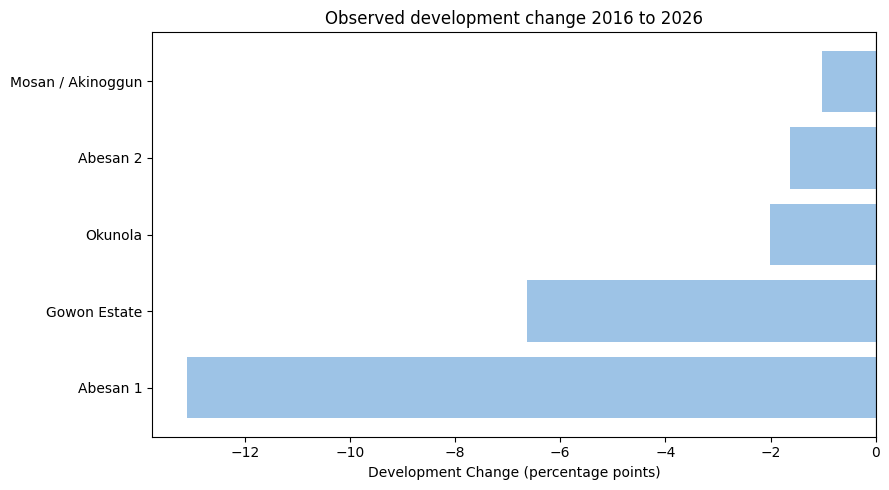

Saved: sprint4_outputs/development_change_bar.png


In [13]:
plot_df = development_df.dropna(subset=["Development Change"]).sort_values("Development Change")
fig, ax = plt.subplots(figsize=(9, 5))
colors = plot_df["Development Change Level"].map(
    {"Low": "#9dc3e6", "Average": "#5b9bd5", "High": "#1f4e79", "Unavailable": "#cccccc"}
)
ax.barh(plot_df["Location"], plot_df["Development Change"], color=colors)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Development Change (percentage points)")
ax.set_title(f"Observed development change {EARLIER_YEAR} to {RECENT_YEAR}")
plt.tight_layout()
Path("sprint4_outputs").mkdir(exist_ok=True)
fig.savefig("sprint4_outputs/development_change_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sprint4_outputs/development_change_bar.png")


In [14]:
# Map Development Change onto town polygons / points
mapped = towns_wgs.merge(
    development_df[["Location", "Development Change", "Development Change Level", "Earlier Development", "Recent Development"]],
    on="Location",
    how="left",
)
mapped_wgs = mapped.to_crs(epsg=4326) if mapped.crs and mapped.crs.to_epsg() != 4326 else mapped.copy()
if mapped_wgs.crs is None:
    mapped_wgs = mapped_wgs.set_crs(epsg=4326)

map_keep = [
    "Location",
    "Development Change",
    "Development Change Level",
    "Earlier Development",
    "Recent Development",
]
change_map_gdf = folium_safe_gdf(mapped_wgs, map_keep)
if "Development Change" in mapped_wgs.columns:
    change_map_gdf["Development Change"] = pd.to_numeric(
        mapped_wgs["Development Change"], errors="coerce"
    )

minx, miny, maxx, maxy = change_map_gdf.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]
m = folium.Map(location=center, zoom_start=11, tiles=None)
add_esri_basemaps(m)

level_colors = {
    "Low": "#9dc3e6",
    "Average": "#5b9bd5",
    "High": "#1f4e79",
    "Unavailable": "#cccccc",
}

priced = change_map_gdf.dropna(subset=["Development Change"])
geom_types = set(change_map_gdf.geometry.geom_type)

if geom_types <= {"Point", "MultiPoint"}:
    change_layer = folium.FeatureGroup(name="Development Change", show=True)
    for _, row in change_map_gdf.iterrows():
        geom = row.geometry
        pts = list(geom.geoms) if geom.geom_type == "MultiPoint" else [geom]
        color = level_colors.get(row.get("Development Change Level"), "#cccccc")
        for pt in pts:
            html = (
                f"<b>{row['Location']}</b><br>"
                f"Change: {row.get('Development Change')} pp<br>"
                f"Level: {row.get('Development Change Level')}<br>"
                f"{EARLIER_YEAR}: {row.get('Earlier Development')}%<br>"
                f"{RECENT_YEAR}: {row.get('Recent Development')}%"
            )
            folium.CircleMarker(
                location=[pt.y, pt.x],
                radius=10,
                color="#1f4e79",
                fill=True,
                fill_color=color,
                fill_opacity=0.85,
                popup=folium.Popup(html, max_width=280),
                tooltip=row["Location"],
            ).add_to(change_layer)
    change_layer.add_to(m)
else:
    def style_feature(feature):
        level = feature["properties"].get("Development Change Level") or "Unavailable"
        return {
            "fillColor": level_colors.get(level, "#cccccc"),
            "color": "#1f4e79",
            "weight": 1.5,
            "fillOpacity": 0.65,
        }

    folium.GeoJson(
        json.loads(change_map_gdf.to_json()),
        name="Development Change",
        style_function=style_feature,
        tooltip=folium.GeoJsonTooltip(
            fields=["Location", "Development Change Level", "Development Change"]
        ),
        popup=folium.GeoJsonPopup(
            fields=[
                "Location",
                "Earlier Development",
                "Recent Development",
                "Development Change",
                "Development Change Level",
            ]
        ),
    ).add_to(m)

m.fit_bounds([[miny, minx], [maxy, maxx]])
folium.LayerControl(collapsed=False).add_to(m)
m.save("sprint4_outputs/development_change_map.html")
print("Saved: sprint4_outputs/development_change_map.html")
m


Saved: sprint4_outputs/development_change_map.html


## 9. Optional: inspect NDBI imagery for one town

Pick a location to visually compare the earlier and recent NDBI layers (built-up proxy).

Use the layer control to switch years. The colorbar legend shows the NDBI stretch used for display:

- **Blue** → lower NDBI (less built-up / more vegetation or water in this stretch)
- **White** → mid values
- **Red** → higher NDBI (more built-up signal in this stretch)


In [15]:
from branca.colormap import LinearColormap

# Change this to any Location name from your GeoJSON
INSPECT_LOCATION = towns_wgs["Location"].iloc[2]

inspect_row = towns_wgs.loc[towns_wgs["Location"] == INSPECT_LOCATION].iloc[0]
inspect_region = gdf_row_to_ee_geometry(inspect_row)

earlier_ndbi = ndbi_image(year_composite(EARLIER_YEAR, inspect_region))
recent_ndbi = ndbi_image(year_composite(RECENT_YEAR, inspect_region))

NDBI_VIS_MIN = -0.2
NDBI_VIS_MAX = 0.3
NDBI_VIS_PALETTE = ["#2166ac", "#f7f7f7", "#b2182b"]
vis = {"min": NDBI_VIS_MIN, "max": NDBI_VIS_MAX, "palette": NDBI_VIS_PALETTE}
earlier_map = earlier_ndbi.getMapId(vis)
recent_map = recent_ndbi.getMapId(vis)

bounds = inspect_region.bounds().getInfo()["coordinates"][0]
lats = [c[1] for c in bounds]
lons = [c[0] for c in bounds]
c_lat, c_lon = (min(lats) + max(lats)) / 2, (min(lons) + max(lons)) / 2

inspect_map = folium.Map(location=[c_lat, c_lon], zoom_start=13, tiles=None)
add_esri_basemaps(inspect_map)
folium.TileLayer(
    tiles=earlier_map["tile_fetcher"].url_format,
    attr="Google Earth Engine",
    name=f"NDBI {EARLIER_YEAR}",
    overlay=True,
    control=True,
).add_to(inspect_map)
folium.TileLayer(
    tiles=recent_map["tile_fetcher"].url_format,
    attr="Google Earth Engine",
    name=f"NDBI {RECENT_YEAR}",
    overlay=True,
    control=True,
).add_to(inspect_map)

ndbi_legend = LinearColormap(
    colors=NDBI_VIS_PALETTE,
    vmin=NDBI_VIS_MIN,
    vmax=NDBI_VIS_MAX,
    caption="NDBI (built-up proxy): blue = lower, red = higher",
)
ndbi_legend.add_to(inspect_map)

folium.LayerControl(collapsed=False).add_to(inspect_map)
print(f"Inspecting: {INSPECT_LOCATION}")
inspect_map


Inspecting: Mosan / Akinoggun


## 10. Export Development Change dataset + chart

Download these for your Sprint 4 submission.


In [16]:
out_dir = Path("sprint4_outputs")
out_dir.mkdir(exist_ok=True)

csv_path = out_dir / "development_change.csv"
json_path = out_dir / "development_change.json"
development_df.to_csv(csv_path, index=False)
development_df.to_json(json_path, orient="records", indent=2)

print("Wrote:")
print(f"  {csv_path}")
print(f"  {json_path}")
print(f"Columns: {list(development_df.columns)}")

try:
    from google.colab import files  # type: ignore
    files.download(str(csv_path))
    files.download(str(json_path))
    files.download("sprint4_outputs/development_change_bar.png")
except Exception:
    print("Not in Colab (or download skipped). Files are in sprint4_outputs/.")


Wrote:
  sprint4_outputs/development_change.csv
  sprint4_outputs/development_change.json
Columns: ['Location', 'Earlier Year', 'Earlier Development', 'Recent Year', 'Recent Development', 'Development Change', 'Development Change Level', 'Notes']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Experiments (required: try at least one)

Ideas:

1. Change `NDBI_THRESHOLD` and re-run Sections 5–6  
2. Inspect another location in Section 9  
3. Temporarily set `RECENT_YEAR` to 2024 or 2025 and compare  
4. Add / swap one town outside your study area  
5. Ask an AI tool to explain the `development_percent` function  

Record: **What I changed → What I expected → What happened → What I learned**


In [18]:
# Experiment starter: show how threshold choice could matter for one town
demo_location = towns_wgs["Location"].iloc[0]
demo_region = gdf_row_to_ee_geometry(
    towns_wgs.loc[towns_wgs["Location"] == demo_location].iloc[0]
)

print(f"Threshold sensitivity demo for: {demo_location} ({RECENT_YEAR})")
for threshold in [-0.05, 0.0, 0.05]:
    ndbi = ndbi_image(year_composite(RECENT_YEAR, demo_region))
    frac = (
        ndbi.gt(threshold)
        .rename("built")
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=demo_region,
            scale=ANALYSIS_SCALE_M,
            maxPixels=1e9,
            bestEffort=True,
        )
        .get("built")
        .getInfo()
    )
    pct = float(frac or 0) * 100
    print(f"  threshold={threshold:+.2f} -> recent development ≈ {pct:.2f}%")


Threshold sensitivity demo for: Abesan 2 (2026)
  threshold=-0.05 -> recent development ≈ 82.74%
  threshold=+0.00 -> recent development ≈ 78.91%
  threshold=+0.05 -> recent development ≈ 69.63%
